In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Importing File

In [2]:
features = pd.read_csv("../data/03_selected/selected_features_with_target.csv")
X = features.drop("target", axis=1)
y = features["target"]

## Standardization of Data

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means

In [5]:
K_range = range(2, 11)
inertias = []
scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init= 10, random_state=42)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)

    silhouette = silhouette_score(X_scaled, kmeans.labels_)
    scores.append(silhouette)


## Graphs 

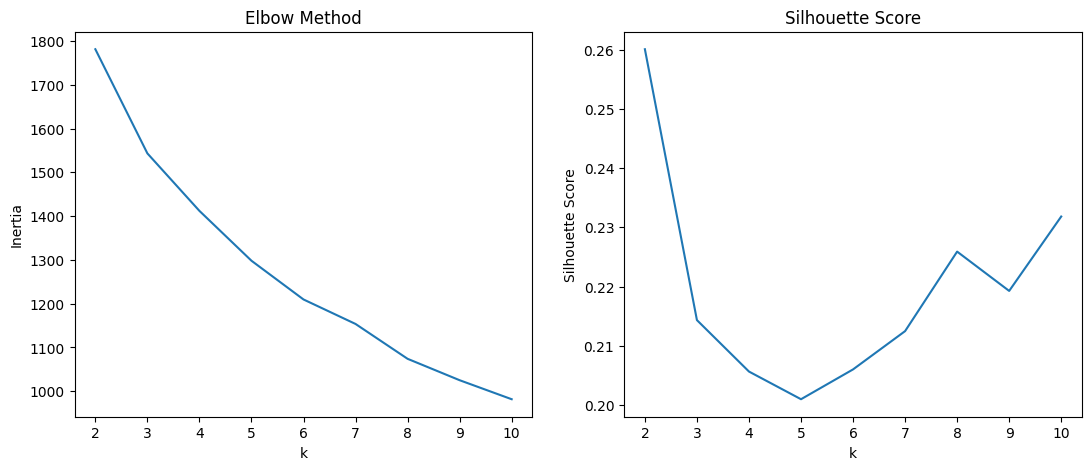

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_range), inertias)
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")


ax2.plot(list(K_range), scores)
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score")


plt.show()

## PCA

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


## Final model with PCA visualization

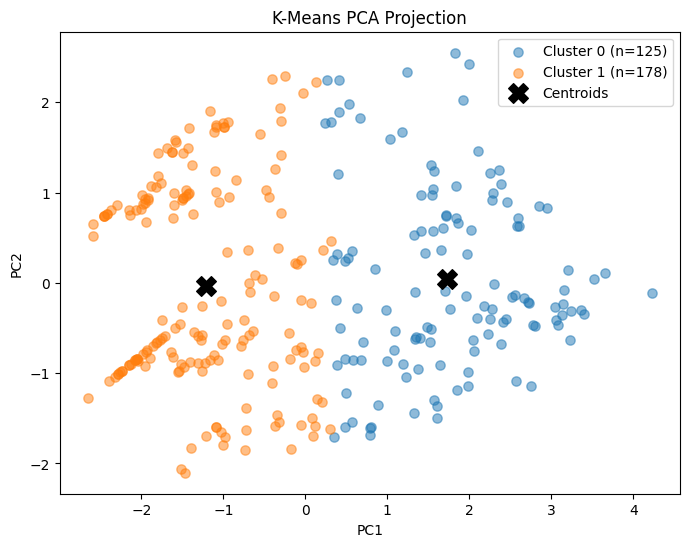

In [14]:
k = 2
km_final = KMeans(n_clusters=k, n_init=10, random_state=42)
km_final.fit(X_scaled)          
labels = km_final.labels_

plt.figure(figsize=(8, 6))
for c in range(k):
    mask = labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=45,
                label=f"Cluster {c} (n={mask.sum()})")

centroids_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", marker="X", s=200, label="Centroids")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means PCA Projection")
plt.legend()
plt.show()


## Centroids

In [15]:
centres = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=X.columns
)
print(centres.round(3))

   thalach  oldpeak     ca  sex_1   cp_4  exang_1  slope_2  thal_7.0
0  134.072    1.754  1.136  0.792  0.840    0.704    0.760     0.664
1  160.517    0.538  0.331  0.601  0.219    0.062    0.253     0.191


## Confusion Matrix

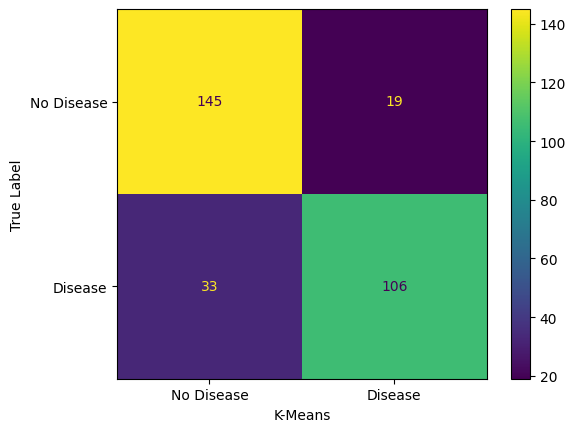

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

flipped_labels = 1 - km_final.labels_

cm = confusion_matrix(y, flipped_labels)
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot()
plt.xlabel("K-Means")
plt.ylabel("True Label")
plt.show()

## ARI Score

In [17]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y, km_final.labels_)
print(f"Adjusted Rand Index: {ari:.4f}")

Adjusted Rand Index: 0.4294
